# Demand Forecasting EDA
### Zara-Inspired Retail Inventory Dataset
Exploring demand patterns, seasonality, stockouts, and feature relationships before modelling.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '../data/raw/retail_store_inventory.csv'

## 1. Load & Basic Overview

In [26]:
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('/', '_')
print(f'Shape: {df.shape}')
print(f'Date range: {df.Date.min().date()} → {df.Date.max().date()}')
print(f'Unique Stores: {df.Store_ID.nunique()}')
print(f'Unique SKUs (Product IDs): {df.Product_ID.nunique()}')
print(f'SKU x Store combos: {df.groupby(["Store_ID","Product_ID"]).ngroups:,}')
df.head()

Shape: (73100, 15)
Date range: 2022-01-01 → 2024-01-01
Unique Stores: 5
Unique SKUs (Product IDs): 20
SKU x Store combos: 100


,Date,Store_ID,Product_ID,Category,Region,Inventory_Level,Units_Sold,Units_Ordered,Demand_Forecast,Price,Discount,Weather_Condition,Holiday_Promotion,Competitor_Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [27]:
df.describe()

,Date,Inventory_Level,Units_Sold,Units_Ordered,Demand_Forecast,Price,Discount,Holiday_Promotion,Competitor_Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2022-12-31 23:59:59.999999744,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408


In [28]:
# Missing values
missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if missing_cols.empty:
    print("✅ No missing values found in any column!")
    print(f"\nAll {len(df.columns)} columns are complete across {len(df):,} rows.")
else:
    missing_cols.plot(kind='bar', title='Missing Values per Column', color='tomato')
    plt.tight_layout()
    plt.show()
    print(missing_cols)

✅ No missing values found in any column!

All 15 columns are complete across 73,100 rows.


## 2. Demand Distribution

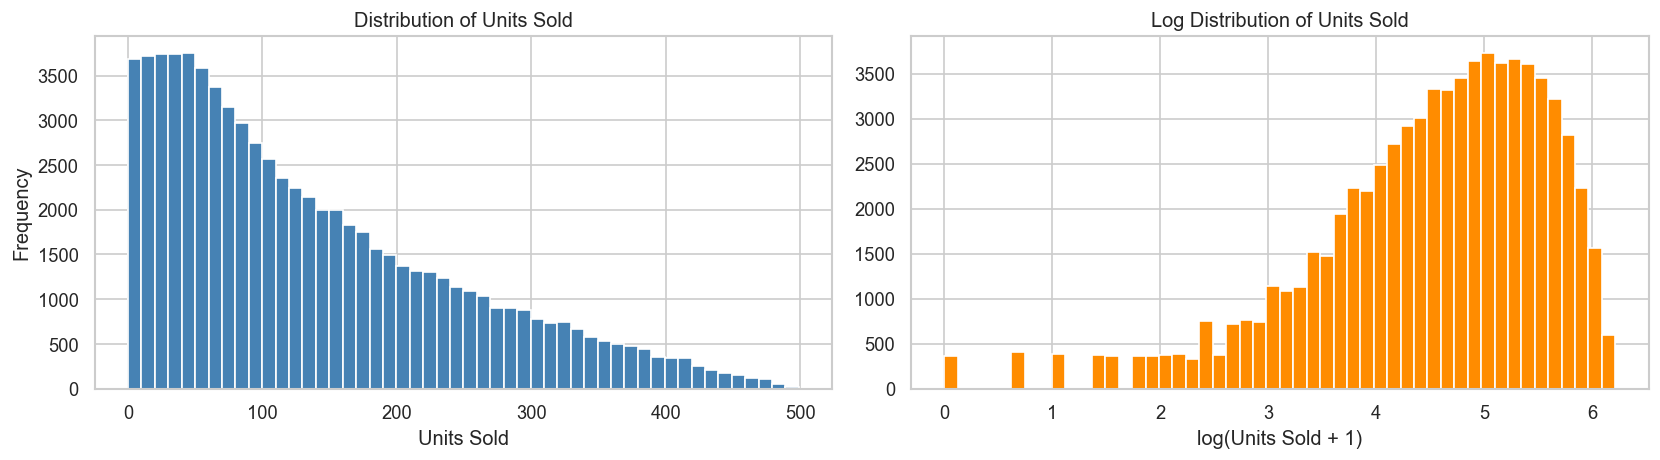

Zero-demand days: 360 (0.5%)


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Units_Sold'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Units Sold')
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['Units_Sold']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Log Distribution of Units Sold')
axes[1].set_xlabel('log(Units Sold + 1)')

plt.tight_layout()
plt.show()

print(f"Zero-demand days: {(df['Units_Sold'] == 0).sum():,} ({(df['Units_Sold'] == 0).mean()*100:.1f}%)")

## 3. Demand by Category

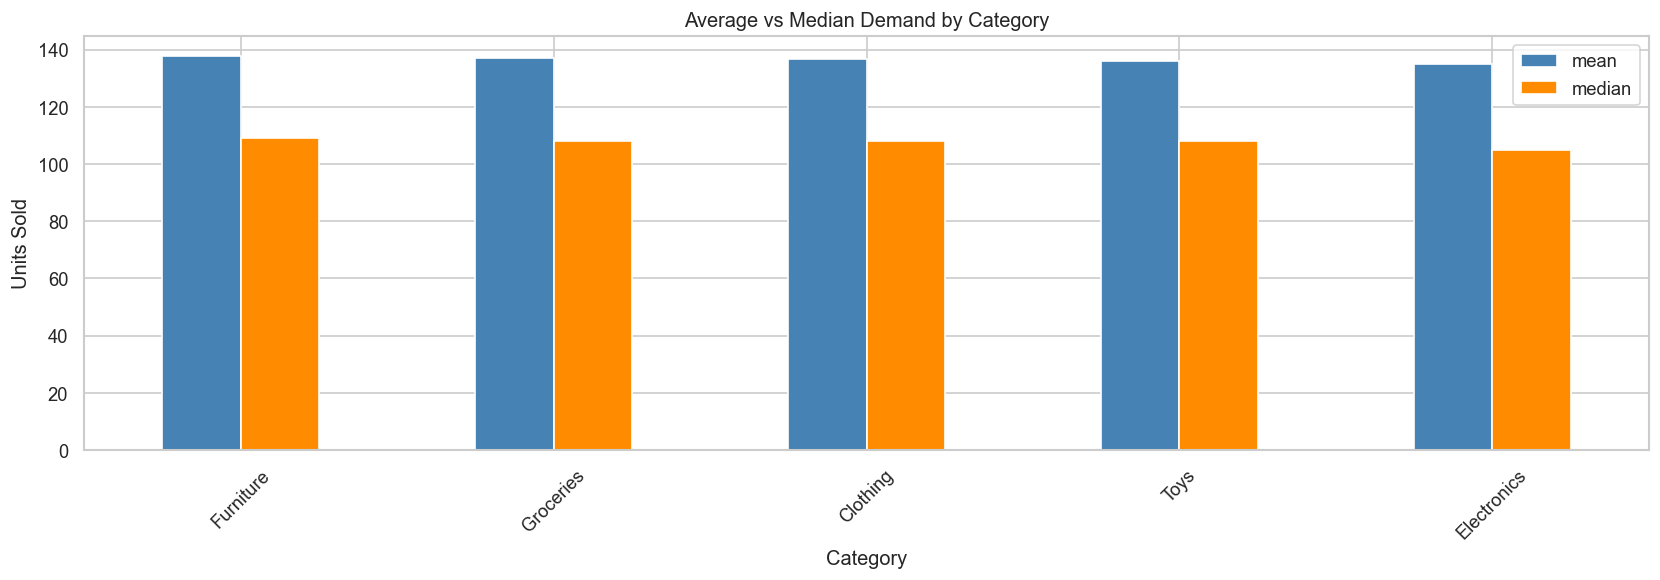

                   mean  median         std
Category                                   
Furniture    137.765630   109.0  110.017747
Groceries    136.916159   108.0  109.256043
Clothing     136.685765   108.0  108.421855
Toys         135.934235   108.0  108.431014
Electronics  135.006680   105.0  108.448033


In [30]:
cat_summary = df.groupby('Category')['Units_Sold'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)

cat_summary[['mean', 'median']].plot(kind='bar', title='Average vs Median Demand by Category', color=['steelblue', 'darkorange'])
plt.xticks(rotation=45)
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()
print(cat_summary)

## 4. Demand Over Time (Trend)

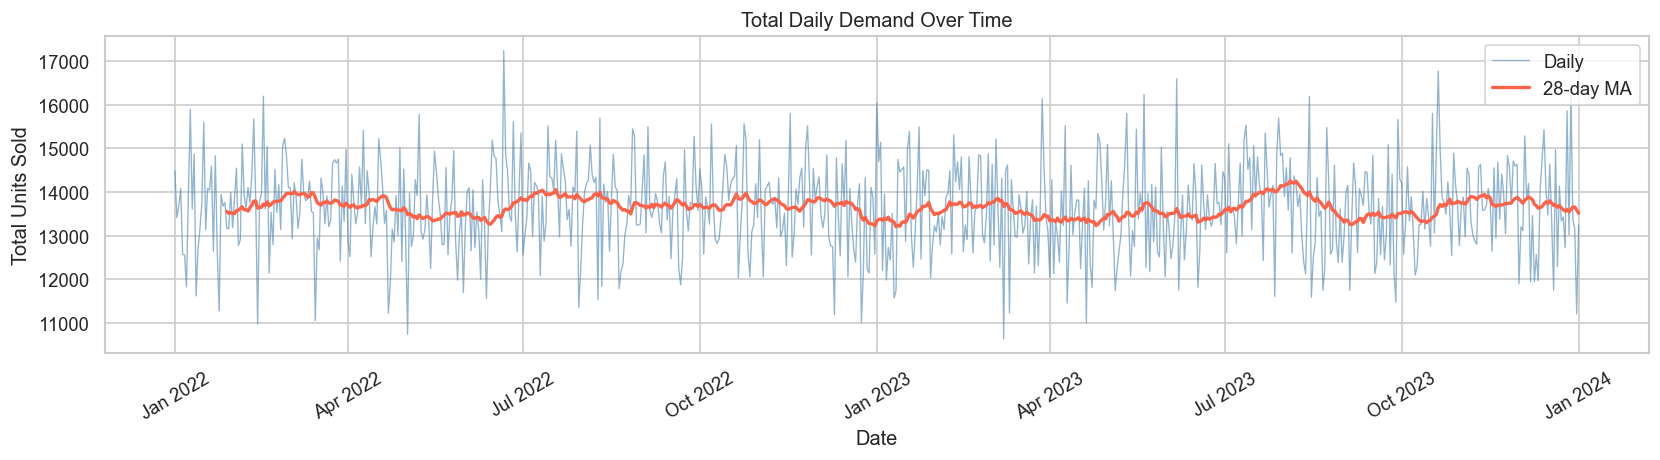

In [31]:
daily = df.groupby('Date')['Units_Sold'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily['Date'], daily['Units_Sold'], color='steelblue', linewidth=0.8, alpha=0.6, label='Daily')
ax.plot(daily['Date'], daily['Units_Sold'].rolling(28).mean(), color='tomato', linewidth=2, label='28-day MA')
ax.set_title('Total Daily Demand Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Total Units Sold')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Seasonality Patterns

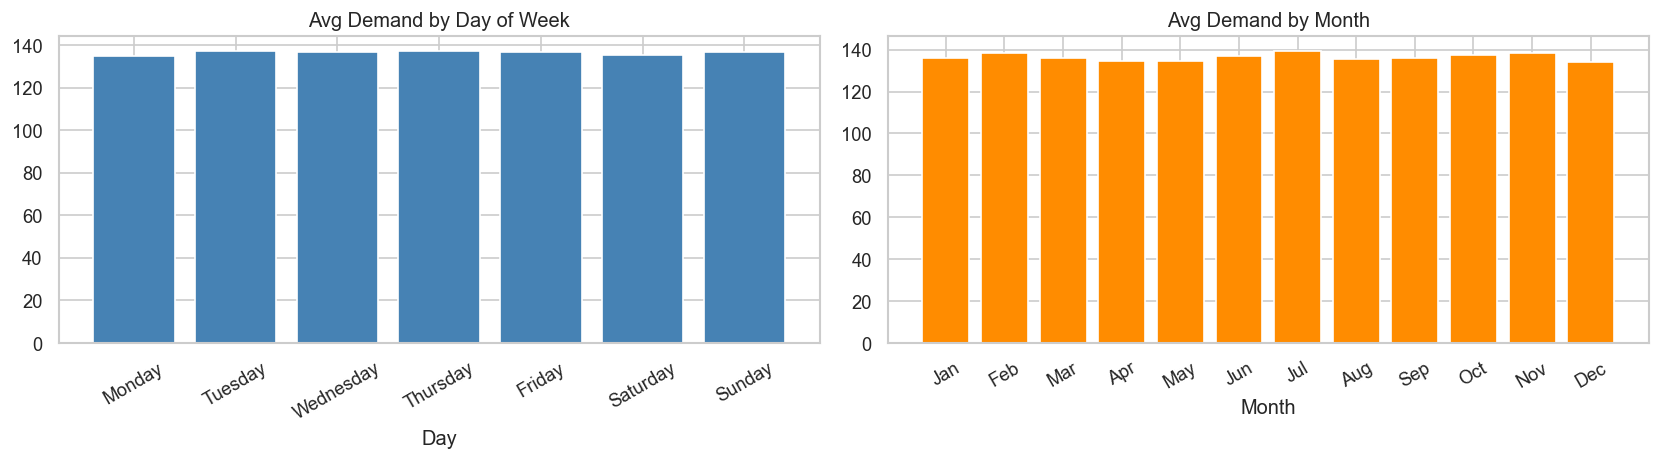

In [32]:
df['day_of_week'] = df['Date'].dt.day_name()
df['month'] = df['Date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week')['Units_Sold'].mean().reindex(dow_order)
axes[0].bar(dow.index, dow.values, color='steelblue')
axes[0].set_title('Avg Demand by Day of Week')
axes[0].set_xlabel('Day')
axes[0].tick_params(axis='x', rotation=30)

monthly = df.groupby('month')['Units_Sold'].mean()
axes[1].bar(monthly.index, monthly.values, color='darkorange')
axes[1].set_title('Avg Demand by Month')
axes[1].set_xlabel('Month')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=30)

plt.tight_layout()
plt.show()

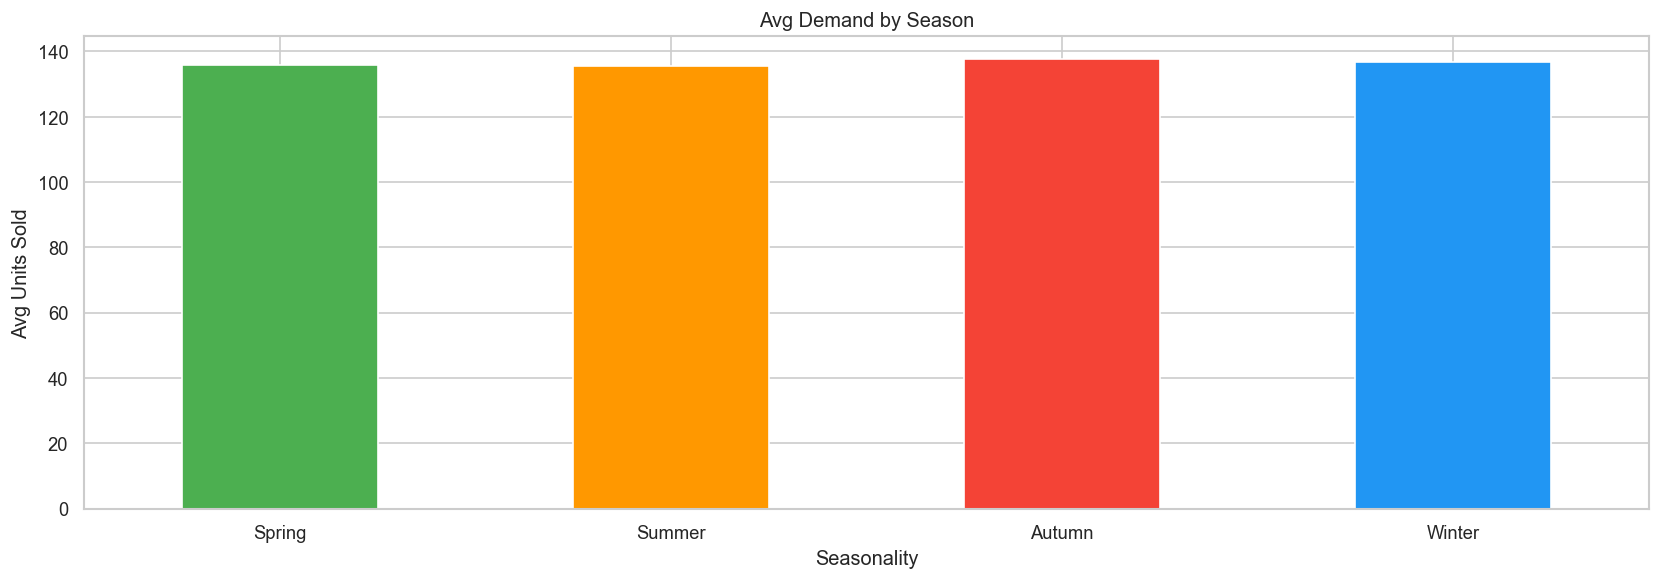

In [33]:
# Demand by Seasonality label
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season = df.groupby('Seasonality')['Units_Sold'].mean().reindex(season_order)
season.plot(kind='bar', color=['#4CAF50','#FF9800','#F44336','#2196F3'], title='Avg Demand by Season')
plt.xticks(rotation=0)
plt.ylabel('Avg Units Sold')
plt.tight_layout()
plt.show()

## 6. Stockout Analysis

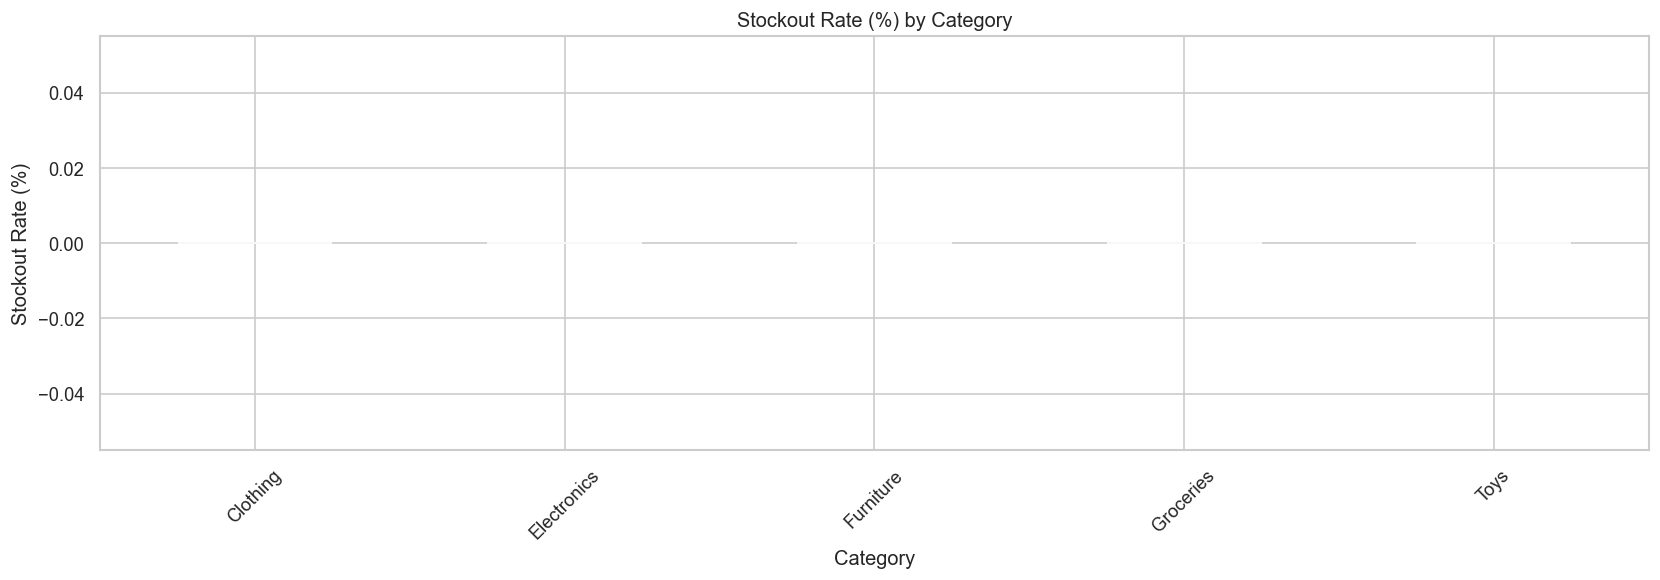

Overall stockout rate: 0.00%


In [34]:
df['stockout'] = (df['Inventory_Level'] == 0).astype(int)
stockout_rate = df.groupby('Category')['stockout'].mean().sort_values(ascending=False) * 100

stockout_rate.plot(kind='bar', color='tomato', title='Stockout Rate (%) by Category')
plt.ylabel('Stockout Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Overall stockout rate: {df['stockout'].mean()*100:.2f}%")

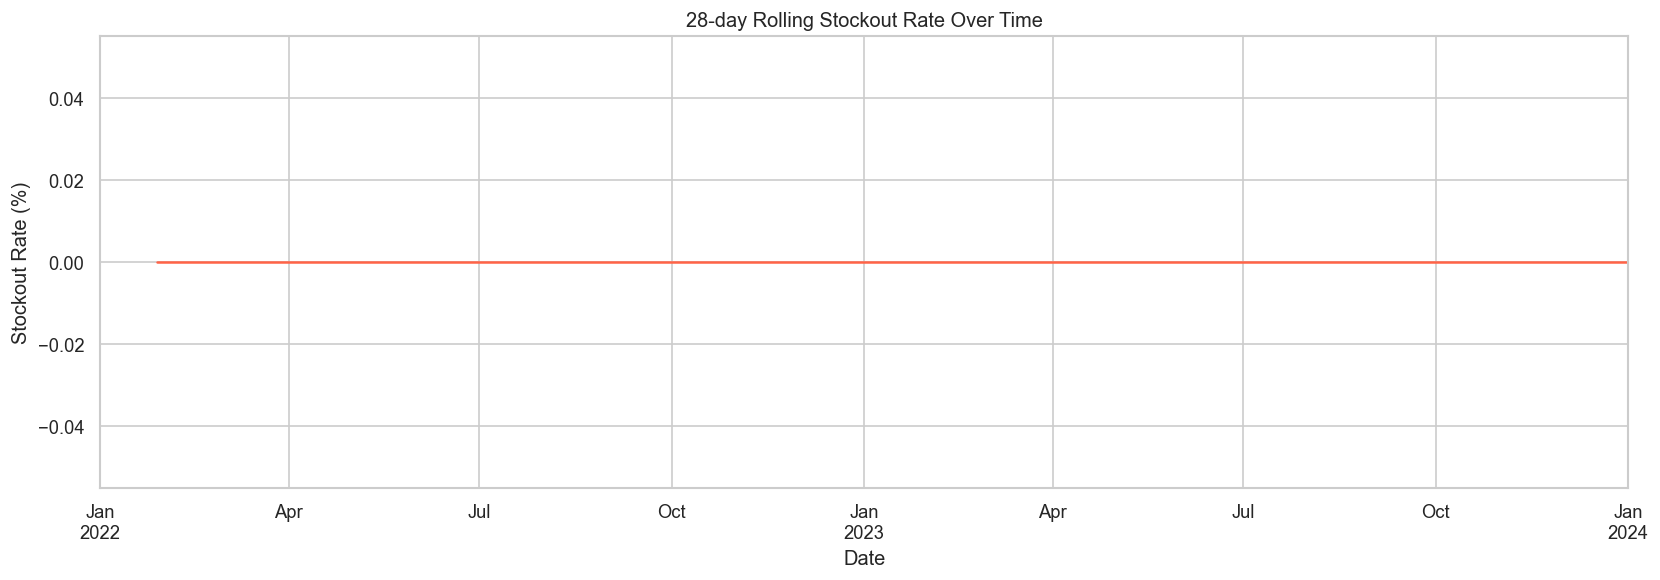

In [35]:
# Stockout rate over time
stockout_time = df.groupby('Date')['stockout'].mean() * 100
stockout_time.rolling(28).mean().plot(color='tomato', title='28-day Rolling Stockout Rate Over Time')
plt.ylabel('Stockout Rate (%)')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

## 7. Impact of Promotions & Weather

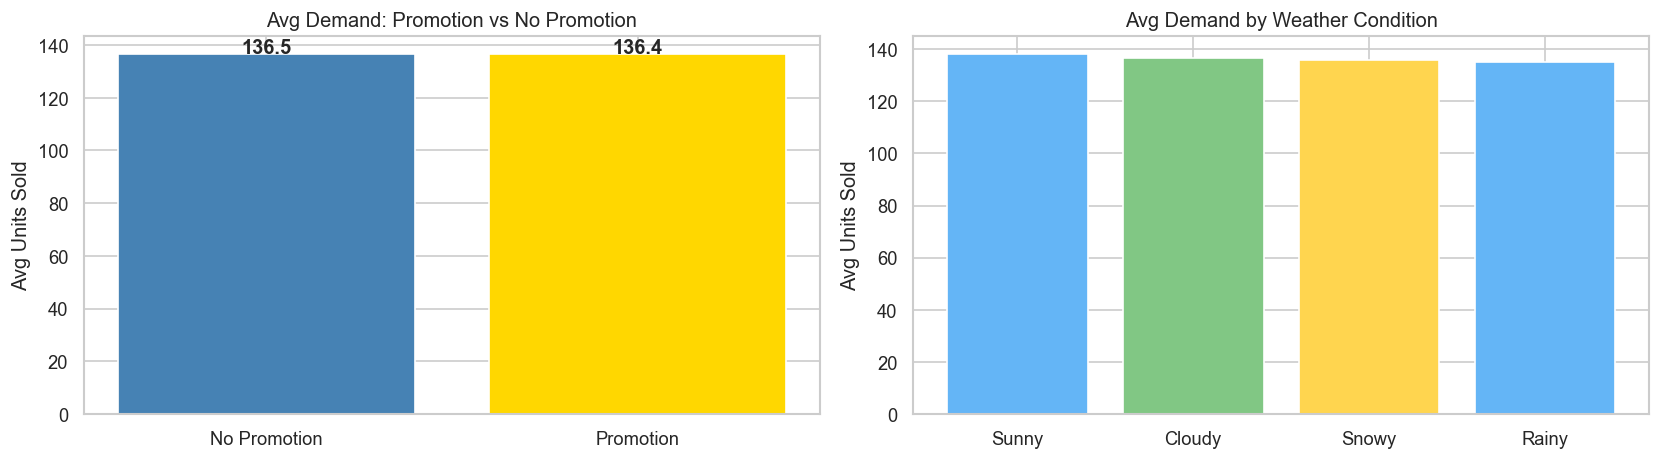

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Promotion impact
promo = df.groupby('Holiday_Promotion')['Units_Sold'].mean()
promo.index = ['No Promotion', 'Promotion']
axes[0].bar(promo.index, promo.values, color=['steelblue', 'gold'])
axes[0].set_title('Avg Demand: Promotion vs No Promotion')
axes[0].set_ylabel('Avg Units Sold')
for i, v in enumerate(promo.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

# Weather impact
weather = df.groupby('Weather_Condition')['Units_Sold'].mean().sort_values(ascending=False)
axes[1].bar(weather.index, weather.values, color=['#64B5F6','#81C784','#FFD54F'])
axes[1].set_title('Avg Demand by Weather Condition')
axes[1].set_ylabel('Avg Units Sold')

plt.tight_layout()
plt.show()

## 8. Price & Discount vs Demand

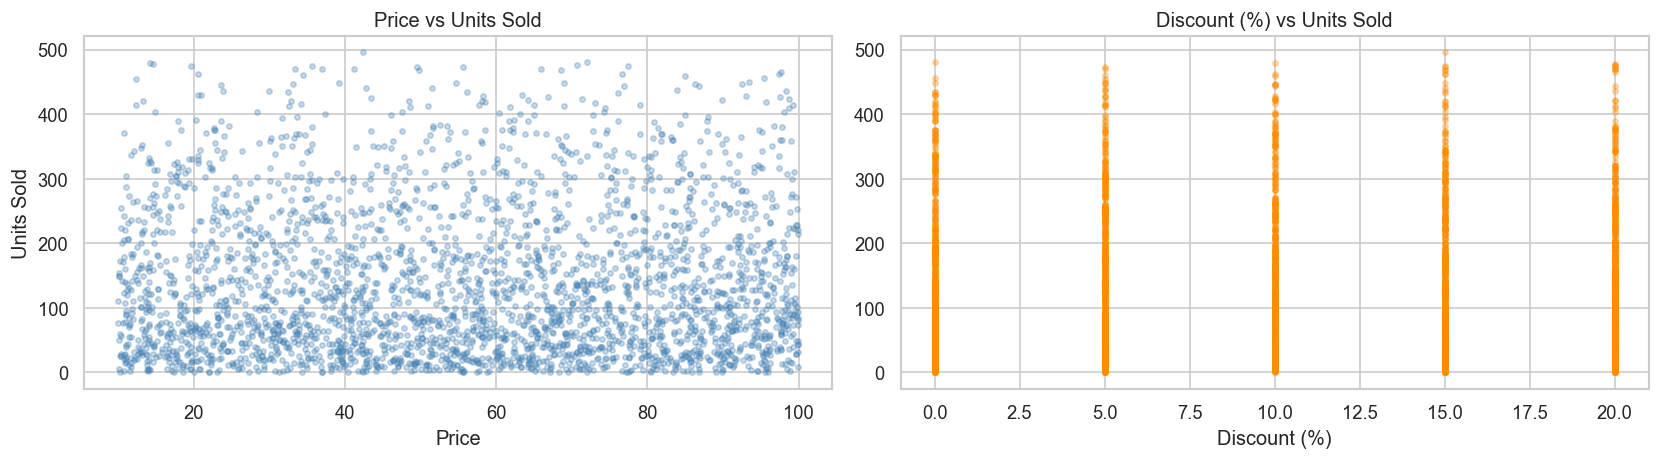

Correlation Price vs Units Sold:    0.001
Correlation Discount vs Units Sold: 0.003


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sample = df.sample(3000, random_state=42)

axes[0].scatter(sample['Price'], sample['Units_Sold'], alpha=0.3, color='steelblue', s=10)
axes[0].set_title('Price vs Units Sold')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Units Sold')

axes[1].scatter(sample['Discount'], sample['Units_Sold'], alpha=0.3, color='darkorange', s=10)
axes[1].set_title('Discount (%) vs Units Sold')
axes[1].set_xlabel('Discount (%)')

plt.tight_layout()
plt.show()

print(f"Correlation Price vs Units Sold:    {df['Price'].corr(df['Units_Sold']):.3f}")
print(f"Correlation Discount vs Units Sold: {df['Discount'].corr(df['Units_Sold']):.3f}")

## 9. Correlation Heatmap

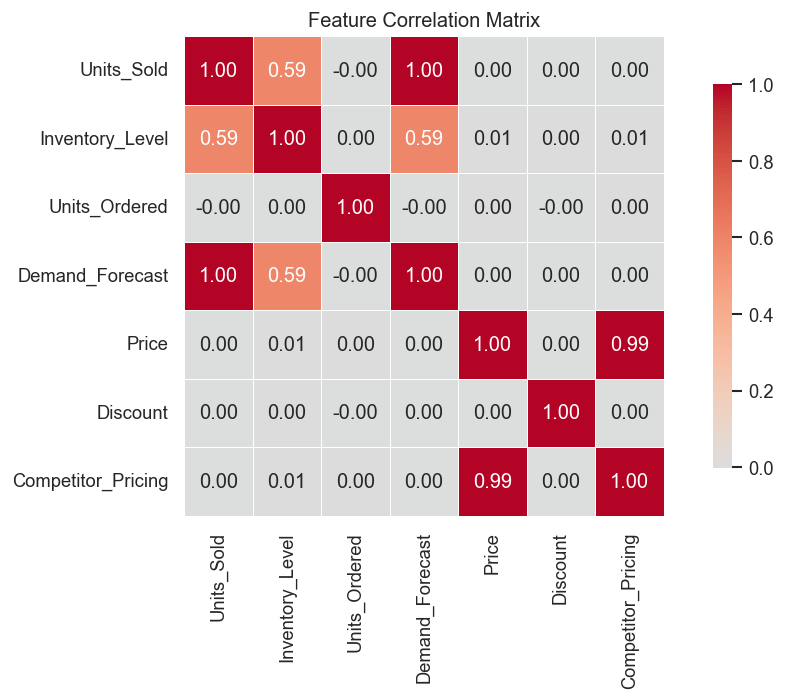

In [38]:
num_cols = ['Units_Sold', 'Inventory_Level', 'Units_Ordered', 'Demand_Forecast', 'Price', 'Discount', 'Competitor_Pricing']
corr = df[num_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 10. Sample SKU Deep Dive

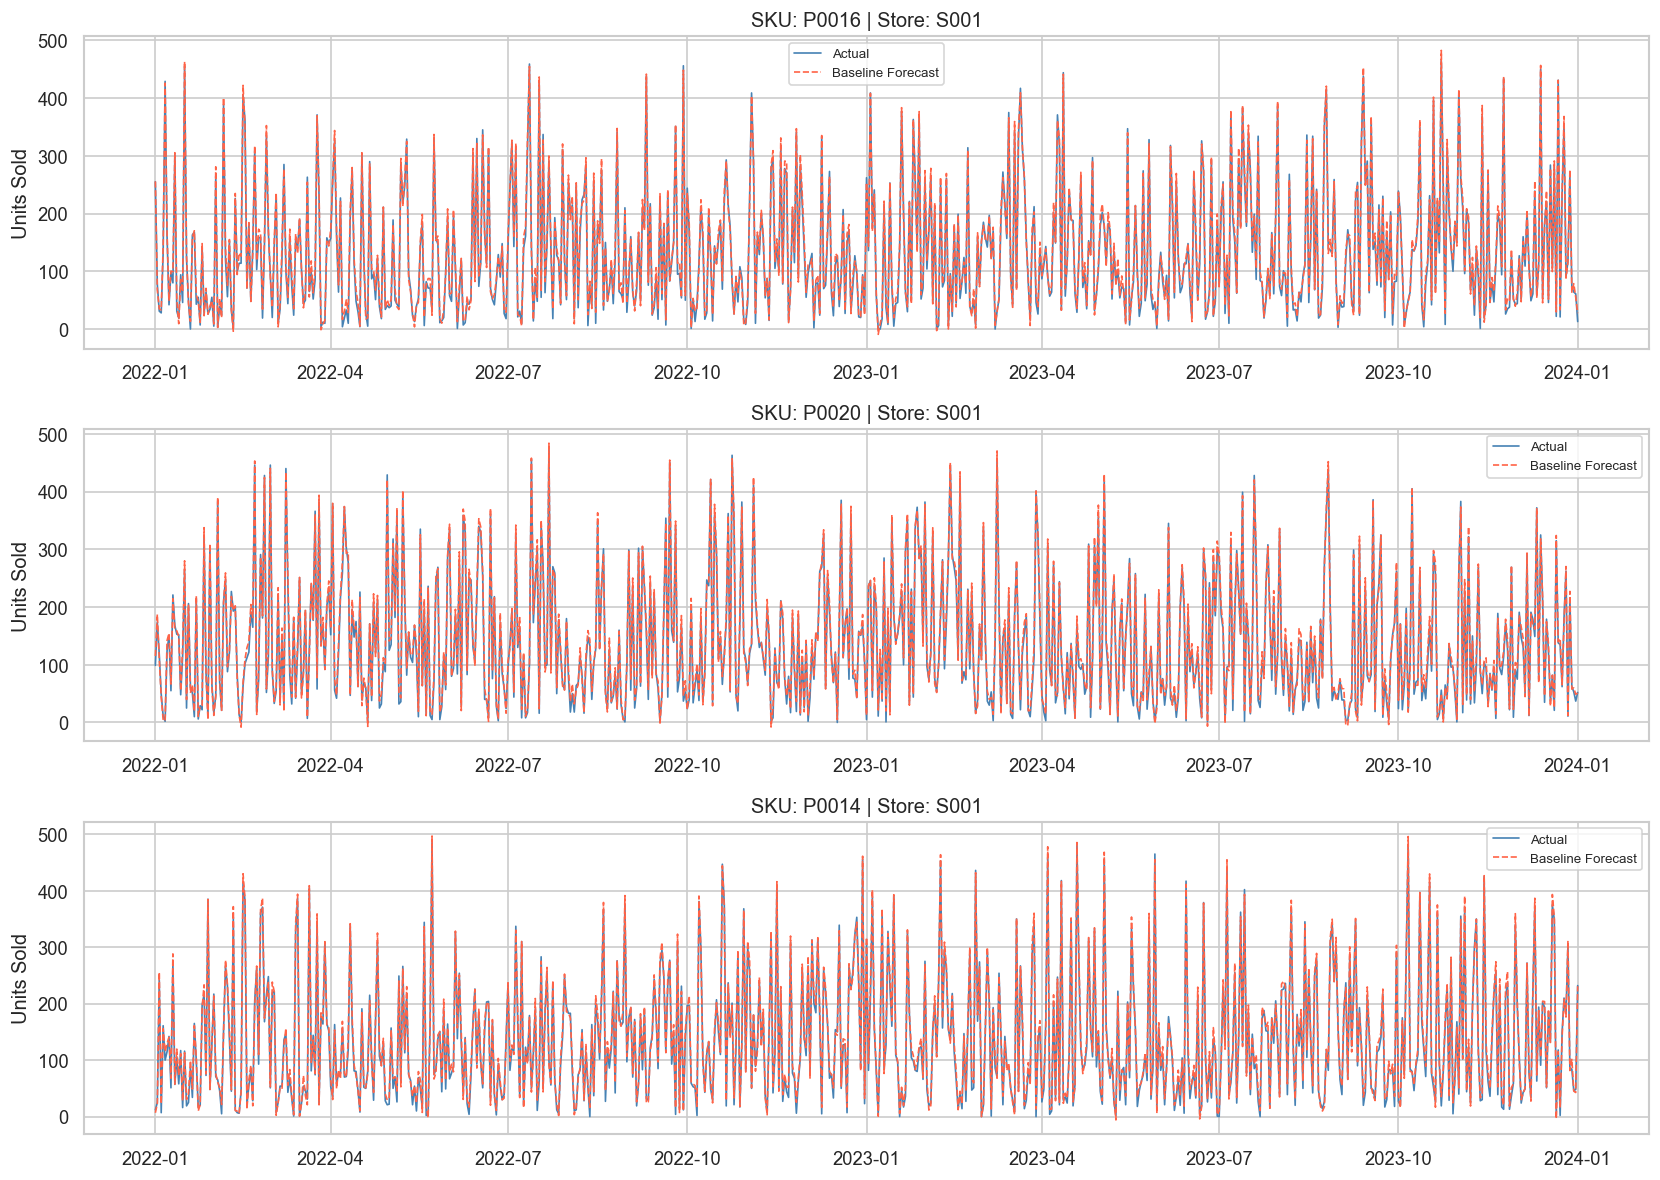

In [39]:
# Pick the top 3 SKUs by total sales
top_skus = df.groupby('Product_ID')['Units_Sold'].sum().nlargest(3).index.tolist()
sample_store = df['Store_ID'].value_counts().index[0]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for i, sku in enumerate(top_skus):
    sku_df = df[(df['Product_ID'] == sku) & (df['Store_ID'] == sample_store)].sort_values('Date')
    axes[i].plot(sku_df['Date'], sku_df['Units_Sold'], color='steelblue', linewidth=1, label='Actual')
    axes[i].plot(sku_df['Date'], sku_df['Demand_Forecast'], color='tomato', linewidth=1, linestyle='--', label='Baseline Forecast')
    axes[i].set_title(f'SKU: {sku} | Store: {sample_store}')
    axes[i].set_ylabel('Units Sold')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 11. EDA Summary

Key findings to inform modelling:

| Insight | Implication |
|---|---|
| Demand has clear weekly & monthly seasonality | Add day-of-week, month features |
| Promotions spike demand | Include `Holiday_Promotion` as feature |
| Weather affects demand | Include `Weather_Condition` (encode) |
| Some SKUs have zero-demand days | Use LightGBM (handles sparsity well) |
| Slow-moving SKUs need separate treatment | Route to Prophet model |
| `Demand_Forecast` baseline exists | Use as benchmark to beat |